# ABE screen analysis

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [2]:
fp = 'ABE_screen_data/ABE_counts'
k = os.listdir(fp)
k = sorted(k)

df = pd.read_csv('CDK_library_final.csv')
pool1 = list(df[df['Pool']=='F1-R1']['gRNA_id'])
pool2 = list(df[df['Pool']=='F2-R2']['gRNA_id'])
pool3 = list(df[df['Pool']=='F3-R3']['gRNA_id'])

name_dict = {'D24-295001' : 'T0_REP1',
'D24-295002' : 'T0_REP2',
'D24-295003' : 'T0_REP3',
'D24-295004' : 'DMSO_REP1', 
'D24-295005' : 'DMSO_REP2', 
'D24-295006' : 'DMSO_REP3', 
'D24-295007' : 'KI-CDK9d-32_100nM_REP1', 
'D24-295008' : 'KI-CDK9d-32_100nM_REP2',
'D24-295009' : 'KI-CDK9d-32_100nM_REP3',
'D24-295010' : 'KI-CDK9d-32_1000nM_REP1', 
'D24-295011' : 'KI-CDK9d-32_1000nM_REP2', 
'D24-295012' : 'KI-CDK9d-32_1000nM_REP3', 
'D24-295013' : 'KI-CDK9d-32N_1250nM_REP1', 
'D24-295014' : 'KI-CDK9d-32N_1250nM_REP2', 
'D24-295015' : 'KI-CDK9d-32N_1250nM_REP3', 
'D24-295016' : 'KI-CDK9d-32N_5000nM_REP1', 
'D24-295017' : 'KI-CDK9d-32N_5000nM_REP2', 
'D24-295018' : 'KI-CDK9d-32N_5000nM_REP3', 
'D24-295019' : 'KB-0742_1500nM_REP1', 
'D24-295020' : 'KB-0742_1500nM_REP2', 
'D24-295021' : 'KB-0742_1500nM_REP3', 
'D24-295022' : 'Senexin_B_2000nM_REP1', 
'D24-295023' : 'Senexin_B_2000nM_REP2',
'D24-295024' : 'Senexin_B_2000nM_REP3',
'D24-295025' : 'Senexin_B_15000nM_REP1',
'D24-295026' : 'Senexin_B_15000nM_REP2',
'D24-295027' : 'Senexin_B_15000nM_REP3', 
'D24-295028' : 'SEL120_4000nM_REP1',
'D24-295029' : 'SEL120_4000nM_REP2', 
'D24-295030' : 'SEL120_4000nM_REP3',
'D24-295031' : 'T0_REP3_CBE'} 


new_name = []
df_holder = []
for i, val in enumerate(k):
    n = name_dict[val[:10]] + '_' + val[11]
    new_name.append(n)
    a = pd.read_csv(f'{fp}/{val}')

    a_pool1 = a[a['Guide_ID'].isin(pool1)]
    a_pool2 = a[a['Guide_ID'].isin(pool2)]
    a_pool3 = a[a['Guide_ID'].isin(pool3)]

    df_holder.append(a_pool1)
    print(f'{n}: pool1: {sum(a_pool1["bc_count"])}, pool2:{sum(a_pool2["bc_count"])}, pool3: {sum(a_pool3["bc_count"])}')


count_dict = dict(zip(new_name, df_holder))

T0_REP1_1: pool1: 18965893.0, pool2:11598.0, pool3: 3220.0
T0_REP1_2: pool1: 19130962.0, pool2:11925.0, pool3: 3208.0
T0_REP2_1: pool1: 18094251.0, pool2:8922.0, pool3: 2495.0
T0_REP2_2: pool1: 18219990.0, pool2:8933.0, pool3: 2414.0
T0_REP3_1: pool1: 14713654.0, pool2:5917.0, pool3: 2659.0
T0_REP3_2: pool1: 14796096.0, pool2:5928.0, pool3: 2775.0
DMSO_REP1_1: pool1: 25155327.0, pool2:6941.0, pool3: 9785.0
DMSO_REP1_2: pool1: 25332706.0, pool2:6945.0, pool3: 9698.0
DMSO_REP2_1: pool1: 15448342.0, pool2:4793.0, pool3: 1533.0
DMSO_REP2_2: pool1: 15515565.0, pool2:4808.0, pool3: 1592.0
DMSO_REP3_1: pool1: 28199985.0, pool2:17812.0, pool3: 6093.0
DMSO_REP3_2: pool1: 28401824.0, pool2:18014.0, pool3: 6333.0
KI-CDK9d-32_100nM_REP1_1: pool1: 16182415.0, pool2:7673.0, pool3: 3927.0
KI-CDK9d-32_100nM_REP1_2: pool1: 16262324.0, pool2:7870.0, pool3: 3883.0
KI-CDK9d-32_100nM_REP2_1: pool1: 22486843.0, pool2:8830.0, pool3: 4248.0
KI-CDK9d-32_100nM_REP2_2: pool1: 22652686.0, pool2:9076.0, pool3: 433

In [3]:
bc_counts_combined = []

for i in name_dict.values():
    flow1 = count_dict[i+'_1']
    flow2 = count_dict[i+'_2']

    c = np.asarray(flow1['bc_count']) + np.asarray(flow2['bc_count'])
    bc_counts_combined.append(c)

    assert list(flow1['Guide_ID']) == list(count_dict[new_name[0]]['Guide_ID'])

count_df  = pd.DataFrame(dict(zip(name_dict.values(), bc_counts_combined)))
count_df_w_gRNA_name = count_df.copy()
count_df_w_gRNA_name['gRNA_id'] = list(count_dict[new_name[0]]['Guide_ID'])


gene_name = []
for i, val in count_df_w_gRNA_name.iterrows():
    gid = val['gRNA_id']
    subset = df[df['gRNA_id']==gid]

    if subset['classification'].values[0]=='intron':
        gene_name.append(subset['Gene'].values[0] + '_intron')
    elif subset['classification'].values[0]=='non-targeting control':
        gene_name.append('NT')
    elif subset['classification'].values[0]=='targeting':
        gene_name.append(subset['Gene'].values[0])

count_df_w_gRNA_name['gene'] = gene_name

In [4]:
count_df_w_gRNA_name = count_df_w_gRNA_name[['gRNA_id', 'gene', 'T0_REP1', 'T0_REP2','T0_REP3', 'DMSO_REP1', 'DMSO_REP2', 'DMSO_REP3',
       'KI-CDK9d-32_100nM_REP1', 'KI-CDK9d-32_100nM_REP2',
       'KI-CDK9d-32_100nM_REP3', 'KI-CDK9d-32_1000nM_REP1',
       'KI-CDK9d-32_1000nM_REP2', 'KI-CDK9d-32_1000nM_REP3',
       'KI-CDK9d-32N_1250nM_REP1', 'KI-CDK9d-32N_1250nM_REP2',
       'KI-CDK9d-32N_1250nM_REP3', 'KI-CDK9d-32N_5000nM_REP1',
       'KI-CDK9d-32N_5000nM_REP2', 'KI-CDK9d-32N_5000nM_REP3',
       'KB-0742_1500nM_REP1', 'KB-0742_1500nM_REP2', 'KB-0742_1500nM_REP3',
       'Senexin_B_2000nM_REP1', 'Senexin_B_2000nM_REP2',
       'Senexin_B_2000nM_REP3', 'Senexin_B_15000nM_REP1',
       'Senexin_B_15000nM_REP2', 'Senexin_B_15000nM_REP3',
       'SEL120_4000nM_REP1', 'SEL120_4000nM_REP2', 'SEL120_4000nM_REP3',]]

count_df_w_gRNA_name = count_df_w_gRNA_name.rename(columns = {'gRNA_id':'sgRNA'})

In [12]:
#and load in plasmid counts from CBE counts file
CBE_counts = pd.read_csv('MAGeCK/CDK_bc_counts.txt', sep='\t')
print(list(CBE_counts['sgRNA'])==list(count_df_w_gRNA_name['sgRNA']))
assert list(CBE_counts['sgRNA'])==list(count_df_w_gRNA_name['sgRNA'])

count_df_w_gRNA_name['Plasmid'] = CBE_counts['Plasmid']

True


In [14]:
count_df_w_gRNA_name.to_csv('MAGeCK/ABE_CDK_bc_counts.txt', sep='\t', index=False)

# MAGeCK analysis

In [15]:
files = ['ABE_DMSO_vs_T0.sgrna_summary.txt',
 'ABE_KB-0742_1500_vs_DMSO.sgrna_summary.txt',
 'ABE_KI-CDK9d-32N_1250_vs_DMSO.sgrna_summary.txt',
 'ABE_KI-CDK9d-32N_5000_vs_DMSO.sgrna_summary.txt',
 'ABE_KI_CDK9d_32_1000_vs_DMSO.sgrna_summary.txt',
 'ABE_KI_CDK9d_32_100_vs_DMSO.sgrna_summary.txt',
 'ABE_SEL120_4000_vs_DMSO.sgrna_summary.txt',
 'ABE_Senexin_B_15000_vs_DMSO.sgrna_summary.txt',
 'ABE_Senexin_B_2000_vs_DMSO.sgrna_summary.txt',
 'ABE_T0_vs_plasmid.sgrna_summary.txt',
 'KI_CDK9d_32_100_vs_T0.sgrna_summary.txt']

names = ['DMSO (vs. T0)',
         'KB-0742 1,500 nM',
         'KI-CDK9d-32N 1,250 nM', 
         'KI-CDK9d-32N 5,000 nM', 
         'KI-CDK9d-32 1,000 nM',
         'KI-CDK9d-32 100 nM',
         'SEL120 4,000 nM',
         'Senexin B 15,000 nM',
         'Senexin B 2,000 nM',
         'T0 (vs. Plasmid)',
         'KI-CDK9d-32 1,000 nM (vs. T0)']


file_names = dict(zip(names, files))

In [18]:
f

'ABE_T0_vs_plasmid.sgrna_summary.txt'

In [60]:
name = 'KI-CDK9d-32N 5,000 nM'

f = file_names[name]

m = pd.read_csv(f'MAGeCK/{f}', sep='\t').sort_values(by='LFC', ascending=False)
m = m.rename(columns = {'sgrna':'gRNA_id'})

p1_edits = pd.read_csv('CDK_Pool1_with_edits.csv')

m1 = pd.merge(m, p1_edits, on='gRNA_id')

introns = ['CDK19_intron', 'CDK9_intron', 'CDK7_intron', 'CDK8_intron']

intron_df = m1[m1['Gene_x'].isin(introns)]
nt_df = m1[m1['Gene_x']=='NT']
non_edited = m1[(m1['classification']=='targeting') & (m1['Edited']==False)]


non_edited['Guide Class'] = 'No Edit\nPredicted'
intron_df['Guide Class'] = 'Intron'
nt_df['Guide Class'] = 'NT'

controls = pd.concat((intron_df, nt_df, non_edited))

m[m['FDR']<.1] #['Gene']


,gRNA_id,Gene,control_count,treatment_count,control_mean,treat_mean,LFC,control_var,adj_var,score,p.low,p.high,p.twosided,FDR,high_in_treatment
0,gRNA_CDK9_targ_1201,CDK9,25649/11169/8769.2,1.7738e+05/1.0466e+05/67434,11169.00,104660.0,3.2280,107710000.0,92727000.0,9.7085,1.00000,1.581900e-22,3.163800e-22,8.637200e-19,True
1,gRNA_CDK9_targ_1199,CDK9,22571/22694/42160,2.6906e+05/1.7899e+05/1.6226e+05,22694.00,178990.0,2.9794,189470000.0,374240000.0,8.0792,1.00000,3.704800e-16,7.409600e-16,1.011400e-12,True
2,gRNA_CDK9_targ_1200,CDK9,13273/10965/13290,2.0014e+05/1.0028e+05/81052,13273.00,100280.0,2.9174,2664500.0,130240000.0,7.6243,1.00000,1.397400e-14,2.794800e-14,2.543300e-11,True
3,gRNA_CDK9_targ_1202,CDK9,8804/9732.8/15281,73518/48437/37655,9732.80,48437.0,2.3151,15823000.0,70722000.0,4.6024,1.00000,2.383000e-06,4.766000e-06,3.252800e-03,True
4,gRNA_nt_8895,NT,14241/9542.7/10602,66284/18476/51207,10602.00,51207.0,2.2719,7182100.0,83686000.0,4.4387,0.99999,5.160600e-06,1.032100e-05,5.635400e-03,True
5,gRNA_CDK9_targ_1674,CDK9,7029.8/5682.9/9933.8,31354/56128/5064,7029.80,31354.0,2.1569,5123700.0,37281000.0,3.9838,0.99996,3.874100e-05,7.748300e-05,3.525500e-02,True
7,gRNA_CDK19_targ_6344,CDK19,383.19/1553.4/356.76,75.164/4600.8/1704.9,383.19,1704.9,2.1506,685030.0,121880.0,3.7858,0.99991,8.867100e-05,1.773400e-04,6.051800e-02,True
6,gRNA_CDK9_targ_1591,CDK9,11845/7677.8/13392,55684/52096/9899.1,11845.00,52096.0,2.1369,9878800.0,104090000.0,3.9453,0.99995,4.542200e-05,9.084400e-05,3.542900e-02,True


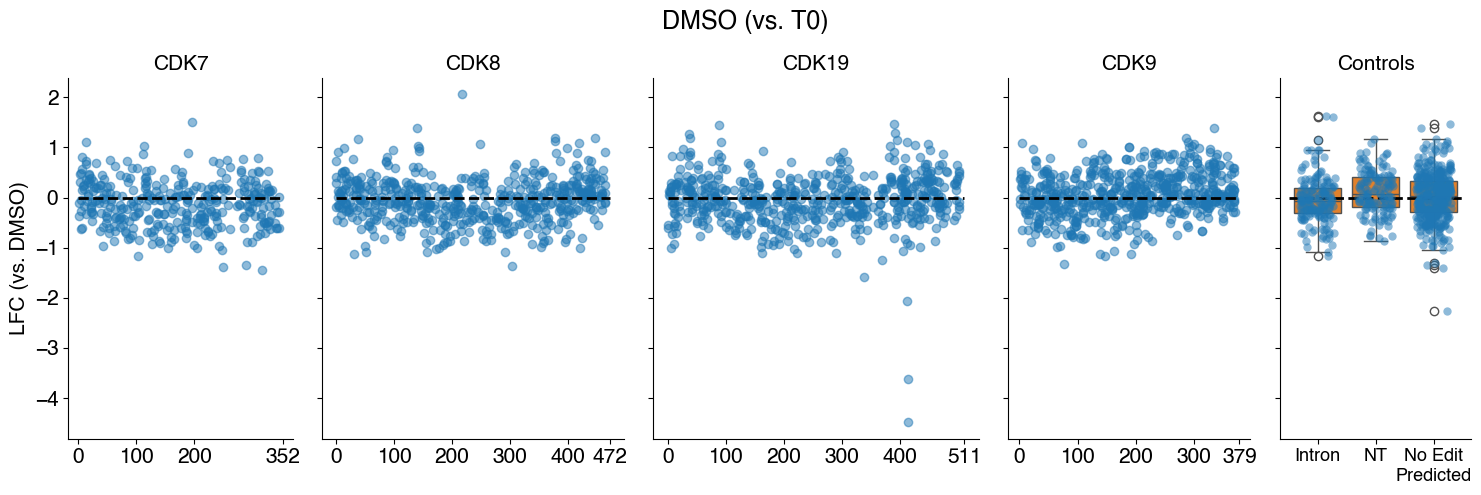

In [22]:
targ = m1[(m1['classification']=='targeting') & (m1['Edited']==True)]

targ = targ[targ['control_mean']>=100]

cutoff = 6
cutoff_low = -7

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']
ax_dict = {'CDK7':0, 'CDK8':1, 'CDK19':2, 'CDK9':3}

fig, ax = plt.subplots(1,5, figsize=(15,5), sharey=True, width_ratios=[352, 472, 511, 379, 300])

xticks = [[0,100,200,352],
          [0,100,200,300,400,472],
          [0,100,200,300,400,511],
          [0,100,200,300,379]]

for i, gene in enumerate(genes):
    s = targ[targ['Gene_x']==gene]

    x = ax_dict[gene]

    bb1 = s[(s['LFC']<cutoff) | (s['LFC']>cutoff_low)]
    bb2 = s[(s['LFC']>=cutoff) | (s['LFC']<=cutoff_low)]


    ax[x].scatter(bb1['Codon_1'], bb1['LFC'], alpha=.5, color='tab:blue')
    ax[x].scatter(bb2['Codon_1'], bb2['LFC'], alpha=.5, color='tab:red')

    ax[x].spines[['right', 'top']].set_visible(False)
    ax[x].tick_params(axis='both', which='major', labelsize=15)
    ax[x].set_xticks(xticks[i])

    t = list(bb2['HGVSp_1'])
    x2=list(bb2['Codon_1'])
    y = list(bb2['LFC'])

    if len(bb2)>0:
        texts = [ax[x].text(x2[i], y[i], t[i], fontsize=12, color='black', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                        foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

        adjust_text(texts,only_move={'points':'y', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))


ax[0].plot([0,352], [0,0], linewidth=2, color='black', linestyle='dashed')
ax[1].plot([0,472], [0,0], linewidth=2, color='black', linestyle='dashed')
ax[2].plot([0,511], [0,0], linewidth=2, color='black', linestyle='dashed')
ax[3].plot([0,379], [0,0], linewidth=2, color='black', linestyle='dashed')

ax[0].set_title('CDK7', fontsize=15)
ax[1].set_title('CDK8', fontsize=15)
ax[2].set_title('CDK19', fontsize=15)
ax[3].set_title('CDK9', fontsize=15)

ax[0].set_ylabel('LFC (vs. DMSO)', fontsize=15)

sns.stripplot(data = controls, x='Guide Class', y='LFC', ax=ax[4], alpha=.5, jitter=.3, s=6)
sns.boxplot(data = controls, x='Guide Class', y='LFC', ax=ax[4])

ax[4].plot([-.5,2.5], [0,0], linewidth=2, color='black', linestyle='dashed')

ax[4].spines[['right', 'top']].set_visible(False)
ax[4].tick_params(axis='both', which='major', labelsize=13)
ax[4].set_xlabel('')
ax[4].set_title('Controls', fontsize=15)

fig.suptitle(name, fontsize=18)
fig.tight_layout()

# TRY COMPARING TO T0 FOR ALL GROUPS? OR PLASMID LIBRARY...

# Edit analysis

In [ ]:
def dna_and_protein_logo(logo_df, wt_proto, dna_logo, merge):

    import logomaker

    ss_logo = logomaker.Logo(logo_df, vpad = .02) #color_scheme='chemistry', vpad=.02)

    # style using Logo methods
    #ss_logo.highlight_position(p=min_cod, color='gold', alpha=.5)
    #ss_logo.highlight_position(p=max_cod, color='gold', alpha=.5)

    ss_logo.style_spines(spines=['left', 'right', 'top'], visible=False)

    ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=12)
    ss_logo.ax.set_yticks([0,25, 50, 75,100])
    ss_logo.ax.set_yticklabels([0,25, 50, 75,100], fontsize=12);
    ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
    ss_logo.ax.set_ylabel('Probability', fontsize=14)

    ss_logo.ax.get_xticks()

    d_nonzero = d4[d4['corr_perc']>0]


    for i, val in d_nonzero.iterrows():
        alt = val['alt']
        loc = val['codon']
        pp = val['corr_perc']
        ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')


    s2 = ''

    dd = d[(d['corr_perc']>0) & (d['HGVSp']!='WT')].sort_values(by='corr_perc', ascending=False)

    for i, val in dd[:4].iterrows():
        pp = val['corr_perc']
        s2 += f"{val['HGVSp']}, {np.round(pp,2)}% "


    try:
        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene_x'].values[0]
    except:
        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]


    ss_logo.ax.set_title(f'{g} {s2}', fontsize=14)

    #and then the DNA logo----------
    logo_df = dna_logo.set_index('Protospacer Location')


    ss_logo = logomaker.Logo(logo_df, vpad = .02) #color_scheme='chemistry', vpad=.02)

    # style using Logo methods
    #ss_logo.highlight_position(p=min_cod, color='gold', alpha=.5)
    #ss_logo.highlight_position(p=max_cod, color='gold', alpha=.5)

    ss_logo.style_spines(spines=['left', 'right', 'top'], visible=False)

    ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=12)
    ss_logo.ax.set_yticks([0,25, 50, 75,100])
    ss_logo.ax.set_yticklabels([0,25, 50, 75,100], fontsize=12);
    ss_logo.ax.set_xlabel('Protospacer Location', fontsize=14)
    ss_logo.ax.set_ylabel('Probability', fontsize=14)

    ss_logo.ax.get_xticks()


    for i, val in enumerate(wt_proto):
        loc = i+1
        bases = ['A','T','C','G']
        bases.remove(val)
        ss_logo.style_single_glyph(c=val, p=loc, color='tab:grey')
        for k in bases:
            ss_logo.style_single_glyph(c=k, p=loc, color='tab:blue')